# Weather 10.20

### Import

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

### Load data

In [2]:
# Load the data
df = pd.read_csv('../data/PerthWeather.csv')

# Explore the data
print("Dataset info:")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
print(df[['MinTemp', 'MaxTemp']].head())

# Clean data - remove missing values
df_clean = df[['MinTemp', 'MaxTemp']].dropna()
print(f"\nAfter removing missing values: {len(df_clean)} observations")

# Extract arrays for computation
mintemp = df_clean['MinTemp'].values
maxtemp = df_clean['MaxTemp'].values

# Basic statistics
print(f"\nSummary statistics:")
print(f"MinTemp - mean: {mintemp.mean():.2f}°C, std: {mintemp.std():.2f}°C, range: [{mintemp.min():.1f}, {mintemp.max():.1f}]")
print(f"MaxTemp - mean: {maxtemp.mean():.2f}°C, std: {maxtemp.std():.2f}°C, range: [{maxtemp.min():.1f}, {maxtemp.max():.1f}]")
print(f"Correlation: {np.corrcoef(mintemp, maxtemp)[0,1]:.3f}")

Dataset info:
Shape: (3193, 24)
Columns: ['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm', 'RainToday', 'RISK_MM', 'RainTomorrow']

First few rows:
   MinTemp  MaxTemp
0      2.7     18.8
1      6.4     20.7
2      6.5     19.9
3      9.5     19.2
4      9.5     16.4

After removing missing values: 3192 observations

Summary statistics:
MinTemp - mean: 12.92°C, std: 5.09°C, range: [-0.6, 29.7]
MaxTemp - mean: 25.03°C, std: 6.11°C, range: [12.8, 44.4]
Correlation: 0.723


### Standardize the X-range

In [3]:
# Standardize the predictor
mintemp_mean = mintemp.mean()
mintemp_std = mintemp.std()
X = (mintemp - mintemp_mean) / mintemp_std
y = maxtemp

print(f"\nStandardized X range: [{X.min():.2f}, {X.max():.2f}]")


Standardized X range: [-2.66, 3.30]


### Define functions

In [4]:
def log_prior(alpha, beta, sigma):
    """
    Weakly informative priors:
    alpha ~ Normal(25, 10)
    beta ~ Normal(0, 5)
    sigma ~ HalfNormal(10)
    """
    if sigma <= 0:
        return -np.inf
    
    log_p = 0
    log_p += stats.norm.logpdf(alpha, loc=25, scale=10)
    log_p += stats.norm.logpdf(beta, loc=0, scale=5)
    log_p += stats.norm.logpdf(sigma, loc=0, scale=10)
    
    return log_p

def log_likelihood(alpha, beta, sigma, X, y):
    """Normal likelihood for linear regression"""
    mu = alpha + beta * X
    return np.sum(stats.norm.logpdf(y, loc=mu, scale=sigma))

def log_posterior(params, X, y):
    """Log posterior (up to constant)"""
    alpha, beta, sigma = params
    lp = log_prior(alpha, beta, sigma)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(alpha, beta, sigma, X, y)

def run_mcmc(X, y, n_iter=50000, n_chains=4):
    """
    Run multiple MCMC chains using Metropolis-Hastings
    """
    # OLS estimates for initialization
    X_with_intercept = np.column_stack([np.ones(len(X)), X])
    beta_ols = np.linalg.lstsq(X_with_intercept, y, rcond=None)[0]
    residuals = y - (beta_ols[0] + beta_ols[1] * X)
    sigma_ols = np.std(residuals)
    
    # Proposal scales (tuned for ~30% acceptance)
    proposal_scales = [0.5, 0.1, 0.1]
    
    # Run multiple chains
    all_samples = []
    all_accept = []
    
    for chain in range(n_chains):
        # Different starting points with small random perturbations
        initial_params = [
            beta_ols[0] + np.random.normal(0, 1),
            beta_ols[1] + np.random.normal(0, 0.1),
            sigma_ols * np.random.uniform(0.8, 1.2)
        ]
        
        samples = np.zeros((n_iter, 3))
        accept = np.zeros(n_iter)
        current = np.array(initial_params)
        current_log_post = log_posterior(current, X, y)
        
        for i in range(n_iter):
            proposal = current + np.random.normal(0, proposal_scales, size=3)
            
            if proposal[2] <= 0:  # sigma must be positive
                accept[i] = 0
                samples[i] = current
                continue
            
            proposal_log_post = log_posterior(proposal, X, y)
            log_alpha = proposal_log_post - current_log_post
            
            if np.log(np.random.random()) < log_alpha:
                current = proposal
                current_log_post = proposal_log_post
                accept[i] = 1
            
            samples[i] = current
        
        all_samples.append(samples)
        all_accept.append(accept)
        print(f"Chain {chain+1}: acceptance rate = {accept.mean():.3f}")
    
    return np.array(all_samples), np.array(all_accept)

def transform_coefficients(alpha_std, beta_std, mintemp_mean, mintemp_std):
    """Convert standardized coefficients back to original units"""
    beta_orig = beta_std / mintemp_std
    alpha_orig = alpha_std - beta_std * mintemp_mean / mintemp_std
    return alpha_orig, beta_orig

### Run the MCMC posterior-simulation

In [5]:
# Run MCMC
print("\nRunning MCMC...")
np.random.seed(42)
all_samples, all_accept = run_mcmc(X, y, n_iter=30000, n_chains=4)

# Remove burn-in and combine chains
burnin = 5000
posterior_samples = all_samples[:, burnin:].reshape(-1, 3)
alpha_std = posterior_samples[:, 0]
beta_std = posterior_samples[:, 1]
sigma = posterior_samples[:, 2]

print(f"\nTotal posterior samples: {len(posterior_samples)}")
print(f"Overall acceptance rate: {(all_accept[:, burnin:].mean()):.3f}")

alpha_orig, beta_orig = transform_coefficients(alpha_std, beta_std, mintemp_mean, mintemp_std)

# Create summary dataframe using pandas
summary_df = pd.DataFrame({
    'Parameter': ['alpha_std', 'beta_std', 'sigma', 'alpha_orig', 'beta_orig'],
    'Mean': [alpha_std.mean(), beta_std.mean(), sigma.mean(), 
             alpha_orig.mean(), beta_orig.mean()],
    'Std': [alpha_std.std(), beta_std.std(), sigma.std(),
            alpha_orig.std(), beta_orig.std()],
    '2.5%': [np.percentile(alpha_std, 2.5), np.percentile(beta_std, 2.5),
             np.percentile(sigma, 2.5), np.percentile(alpha_orig, 2.5),
             np.percentile(beta_orig, 2.5)],
    '97.5%': [np.percentile(alpha_std, 97.5), np.percentile(beta_std, 97.5),
              np.percentile(sigma, 97.5), np.percentile(alpha_orig, 97.5),
              np.percentile(beta_orig, 97.5)]
})

print("\n" + "="*70)
print("POSTERIOR SUMMARIES")
print("="*70)
print(summary_df.to_string(index=False))

# Probability that beta > 0
prob_beta_positive = (beta_orig > 0).mean()
print(f"\nProbability that slope > 0: {prob_beta_positive:.4f}")


Running MCMC...
Chain 1: acceptance rate = 0.089
Chain 2: acceptance rate = 0.087
Chain 3: acceptance rate = 0.088
Chain 4: acceptance rate = 0.084

Total posterior samples: 100000
Overall acceptance rate: 0.087

POSTERIOR SUMMARIES
 Parameter      Mean      Std      2.5%     97.5%
 alpha_std 25.034628 0.075086 24.889506 25.179750
  beta_std  4.421689 0.075276  4.275650  4.570112
     sigma  4.225048 0.053820  4.123798  4.332975
alpha_orig 13.800948 0.203800 13.397063 14.193520
 beta_orig  0.869196 0.014797  0.840488  0.898373

Probability that slope > 0: 1.0000


In [8]:
# Generate posterior predictions
n_samples_to_use = min(2000, len(posterior_samples))

# Efficient prediction using numpy broadcasting
idx = np.random.choice(len(posterior_samples), n_samples_to_use, replace=False)
alpha_subset = alpha_std[idx]
beta_subset = beta_std[idx]
sigma_subset = sigma[idx]

# Generate predictions
mu_matrix = alpha_subset[:, np.newaxis] + beta_subset[:, np.newaxis] * X[np.newaxis, :]
y_pred_matrix = np.random.normal(mu_matrix, sigma_subset[:, np.newaxis])

# Point predictions and intervals
y_pred_mean = y_pred_matrix.mean(axis=0)
y_pred_lower = np.percentile(y_pred_matrix, 2.5, axis=0)
y_pred_upper = np.percentile(y_pred_matrix, 97.5, axis=0)

# Calculate metrics
ss_res = np.sum((y - y_pred_mean)**2)
ss_tot = np.sum((y - y.mean())**2)
r_squared = 1 - (ss_res / ss_tot)
residuals = y - y_pred_mean

# Create results dataframe
results_df = pd.DataFrame({
    'Observed': y,
    'Predicted': y_pred_mean,
    'Residual': residuals,
    'CI_lower': y_pred_lower,
    'CI_upper': y_pred_upper,
    'MinTemp': mintemp
})

print("\n" + "="*70)
print("MODEL FIT METRICS")
print("="*70)
print(f"R-squared: {r_squared:.4f}")
print(f"RMSE: {np.sqrt(np.mean(residuals**2)):.3f}°C")
print(f"MAE: {np.mean(np.abs(residuals)):.3f}°C")
print(f"Coverage of 95% CI: {((y >= y_pred_lower) & (y <= y_pred_upper)).mean():.3f}")


MODEL FIT METRICS
R-squared: 0.5225
RMSE: 4.225°C
MAE: 3.466°C
Coverage of 95% CI: 0.959


### Visualize

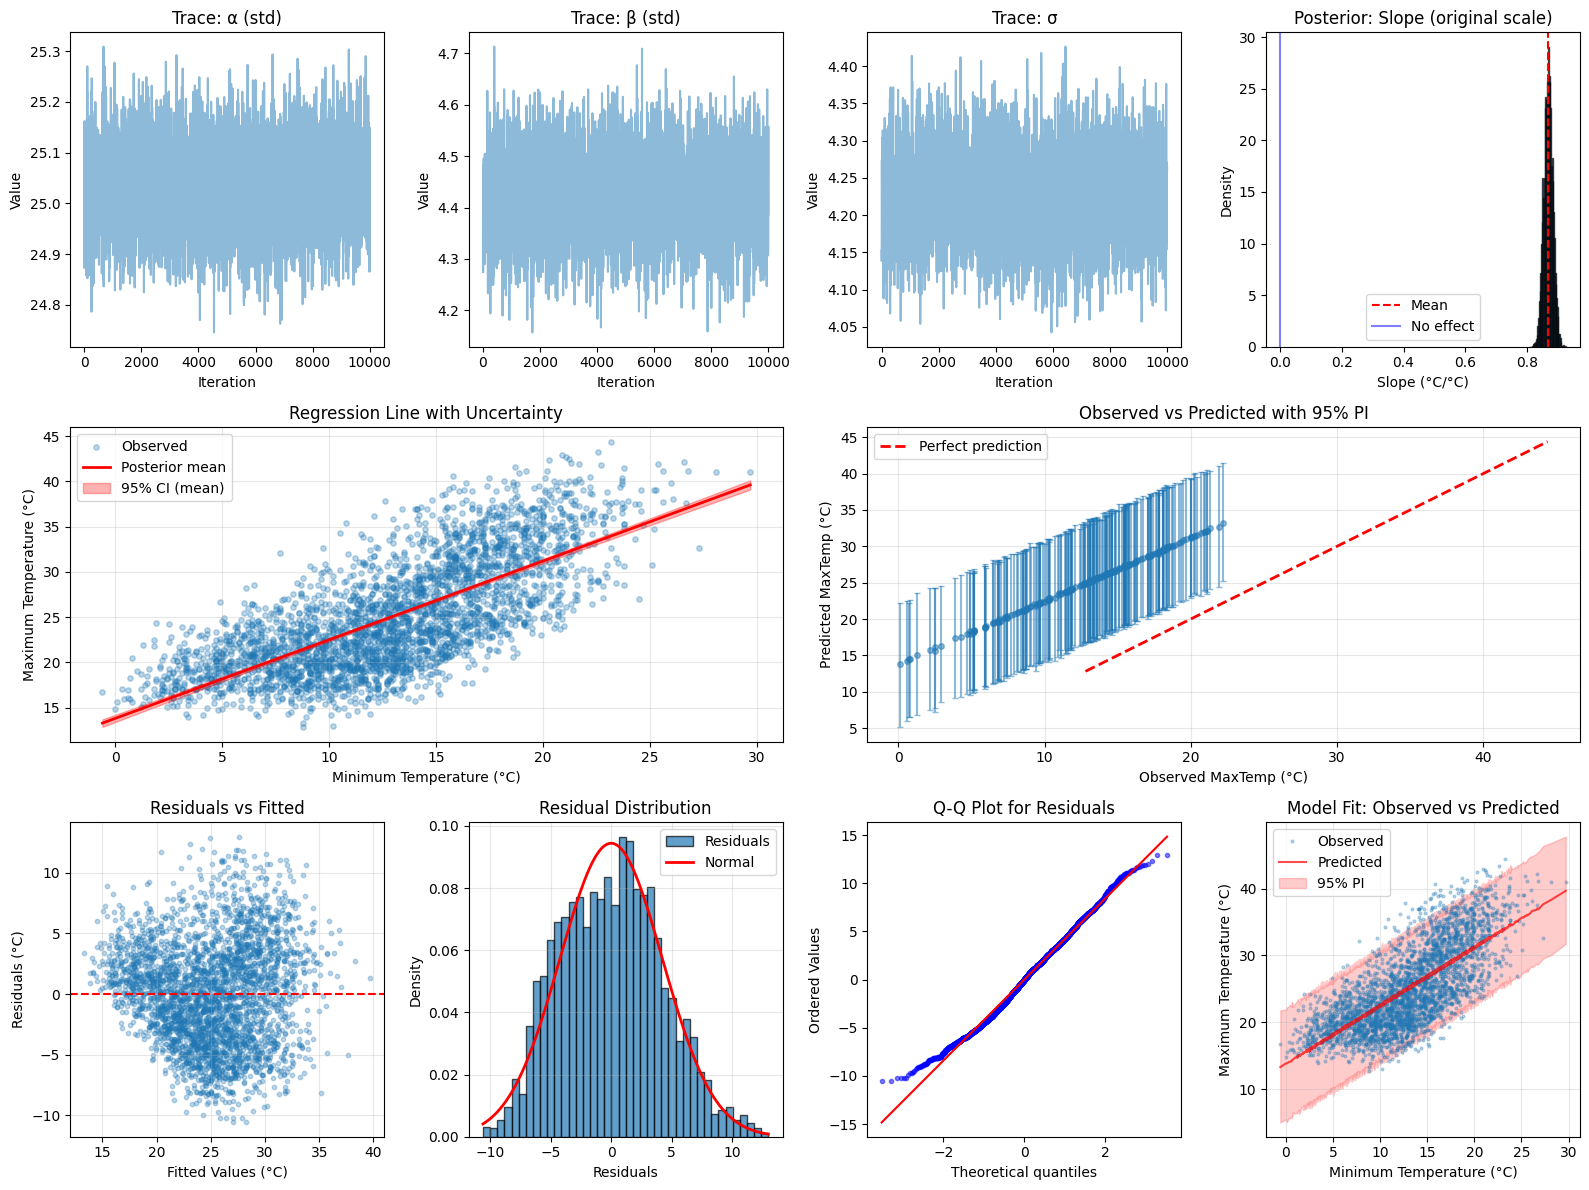

In [9]:
# Create a comprehensive figure
fig = plt.figure(figsize=(16, 12))

# 1. Trace plots
ax1 = plt.subplot(3, 4, 1)
ax1.plot(alpha_std[::10], alpha=0.5)
ax1.set_title('Trace: α (std)')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Value')

ax2 = plt.subplot(3, 4, 2)
ax2.plot(beta_std[::10], alpha=0.5)
ax2.set_title('Trace: β (std)')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Value')

ax3 = plt.subplot(3, 4, 3)
ax3.plot(sigma[::10], alpha=0.5)
ax3.set_title('Trace: σ')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('Value')

# 2. Posterior distributions
ax4 = plt.subplot(3, 4, 4)
ax4.hist(beta_orig, bins=50, density=True, alpha=0.7, edgecolor='black')
ax4.axvline(beta_orig.mean(), color='red', linestyle='--', label='Mean')
ax4.axvline(0, color='blue', linestyle='-', alpha=0.5, label='No effect')
ax4.set_xlabel('Slope (°C/°C)')
ax4.set_ylabel('Density')
ax4.set_title('Posterior: Slope (original scale)')
ax4.legend()

# 3. Regression with uncertainty
ax5 = plt.subplot(3, 4, (5, 6))
# Sort by mintemp for clean line
sort_idx = np.argsort(mintemp)
ax5.scatter(mintemp, y, alpha=0.3, s=15, label='Observed')

# Calculate credible band for mean response
x_range = np.linspace(mintemp.min(), mintemp.max(), 100)
X_range_std = (x_range - mintemp_mean) / mintemp_std

# Use vectorized operations
mu_mean = np.zeros_like(x_range)
mu_lower = np.zeros_like(x_range)
mu_upper = np.zeros_like(x_range)

for i, x_std in enumerate(X_range_std):
    mu_samples = alpha_std + beta_std * x_std
    mu_mean[i] = np.mean(mu_samples)
    mu_lower[i] = np.percentile(mu_samples, 2.5)
    mu_upper[i] = np.percentile(mu_samples, 97.5)

ax5.plot(x_range, mu_mean, 'r-', linewidth=2, label='Posterior mean')
ax5.fill_between(x_range, mu_lower, mu_upper, color='red', alpha=0.3, label='95% CI (mean)')
ax5.set_xlabel('Minimum Temperature (°C)')
ax5.set_ylabel('Maximum Temperature (°C)')
ax5.set_title('Regression Line with Uncertainty')
ax5.legend()
ax5.grid(True, alpha=0.3)

# 4. Prediction intervals
ax6 = plt.subplot(3, 4, (7, 8))
# Plot a subset for clarity
subset_idx = np.random.choice(len(mintemp), 200, replace=False)
ax6.errorbar(mintemp[subset_idx], y_pred_mean[subset_idx], 
             yerr=[y_pred_mean[subset_idx] - y_pred_lower[subset_idx],
                   y_pred_upper[subset_idx] - y_pred_mean[subset_idx]],
             fmt='o', alpha=0.5, capsize=2, capthick=1, markersize=4)
ax6.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Perfect prediction')
ax6.set_xlabel('Observed MaxTemp (°C)')
ax6.set_ylabel('Predicted MaxTemp (°C)')
ax6.set_title('Observed vs Predicted with 95% PI')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 5. Residual analysis
ax7 = plt.subplot(3, 4, 9)
ax7.scatter(y_pred_mean, residuals, alpha=0.3, s=10)
ax7.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax7.set_xlabel('Fitted Values (°C)')
ax7.set_ylabel('Residuals (°C)')
ax7.set_title('Residuals vs Fitted')
ax7.grid(True, alpha=0.3)

ax8 = plt.subplot(3, 4, 10)
ax8.hist(residuals, bins=40, density=True, alpha=0.7, edgecolor='black', label='Residuals')
x_vals = np.linspace(residuals.min(), residuals.max(), 100)
ax8.plot(x_vals, stats.norm.pdf(x_vals, 0, residuals.std()), 'r-', linewidth=2, label='Normal')
ax8.set_xlabel('Residuals')
ax8.set_ylabel('Density')
ax8.set_title('Residual Distribution')
ax8.legend()
ax8.grid(True, alpha=0.3)

# 6. Q-Q plot
ax9 = plt.subplot(3, 4, 11)
stats.probplot(residuals, dist="norm", plot=ax9)
ax9.set_title('Q-Q Plot for Residuals')
ax9.get_lines()[0].set_marker('o')
ax9.get_lines()[0].set_markersize(3)
ax9.get_lines()[0].set_alpha(0.5)

# 7. Model comparison (theoretical vs actual)
ax10 = plt.subplot(3, 4, 12)
results_df_sorted = results_df.sort_values('MinTemp')
ax10.plot(results_df_sorted['MinTemp'], results_df_sorted['Observed'], 'o', alpha=0.3, markersize=2, label='Observed')
ax10.plot(results_df_sorted['MinTemp'], results_df_sorted['Predicted'], 'r-', alpha=0.7, label='Predicted')
ax10.fill_between(results_df_sorted['MinTemp'], 
                  results_df_sorted['CI_lower'], 
                  results_df_sorted['CI_upper'], 
                  alpha=0.2, color='red', label='95% PI')
ax10.set_xlabel('Minimum Temperature (°C)')
ax10.set_ylabel('Maximum Temperature (°C)')
ax10.set_title('Model Fit: Observed vs Predicted')
ax10.legend(loc='upper left')
ax10.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

Looking at the plot is is easy to see that the regression was successful in capturing the relation in minimum and maximum temperatures.

The model however seems to mispredict on the extreme ends which could indicate a case of non-linearity (as seen in the Q-Q plot).

The model could be better if temporal dependencies were considered.